# DINOv2

Training DINOv2 small model. Only using pretrained model with regularization and augmentation. Trying how the model performs if we freeze the whole backbone and finetune just the head, finetune only the final transformer blocks or finetune the whole backbone + head.

In [1]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

### Pretrained DINOv2 with finetuning the whole backbone

Loading DINOv2 Small...


Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Epoch 1/20 | Train: 21.92% | Val: 30.62% | LR: 0.000100
Epoch 2/20 | Train: 30.29% | Val: 35.50% | LR: 0.000100
Epoch 3/20 | Train: 34.02% | Val: 37.94% | LR: 0.000100
Epoch 4/20 | Train: 34.74% | Val: 37.40% | LR: 0.000100
Epoch 5/20 | Train: 36.10% | Val: 34.96% | LR: 0.000100
Epoch 6/20 | Train: 36.10% | Val: 39.30% | LR: 0.000100
Epoch 7/20 | Train: 39.97% | Val: 36.18% | LR: 0.000100
Epoch 8/20 | Train: 38.95% | Val: 41.33% | LR: 0.000100
Epoch 9/20 | Train: 39.85% | Val: 36.59% | LR: 0.000100
Epoch 10/20 | Train: 41.14% | Val: 39.84% | LR: 0.000100
Epoch 11/20 | Train: 42.84% | Val: 38.35% | LR: 0.000100
Epoch 12/20 | Train: 44.02% | Val: 41.19% | LR: 0.000100
Epoch 13/20 | Train: 44.60% | Val: 43.09% | LR: 0.000100
Epoch 14/20 | Train: 46.42% | Val: 42.55% | LR: 0.000100
Epoch 15/20 | Train: 46.76% | Val: 43.22% | LR: 0.000100
Epoch 16/20 | Train: 47.83% | Val: 41.60% | LR: 0.000100
Epoch 17/20 | Train: 48.08% | Val: 43.50% | LR: 0.000100
Epoch 18/20 | Train: 48.47% | Val: 42.68

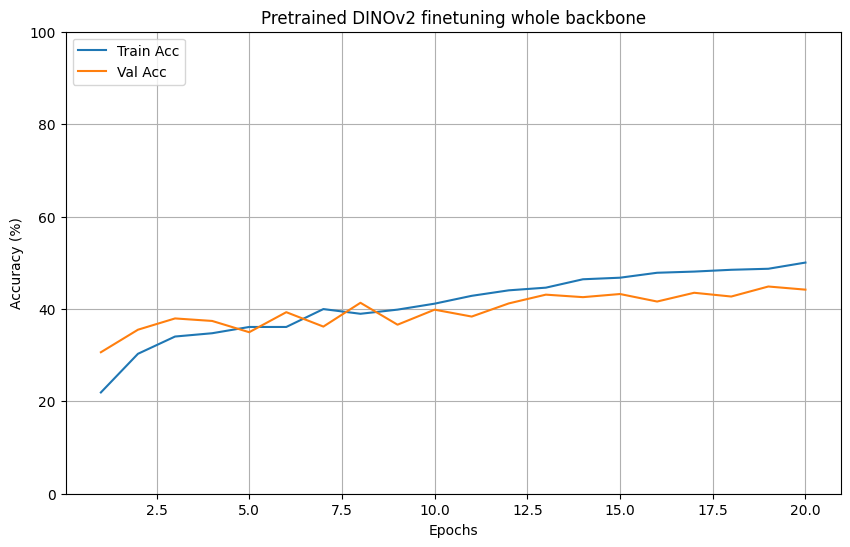


Final Test Accuracy: 44.84%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2_small",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone="finetune_all",
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-4
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained DINOv2 finetuning whole backbone")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained DINOv2 with frozen backbone

Loading DINOv2 Small...


Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main


Epoch 1/20 | Train: 19.86% | Val: 27.78% | LR: 0.000100
Epoch 2/20 | Train: 23.89% | Val: 32.79% | LR: 0.000100
Epoch 3/20 | Train: 26.01% | Val: 35.91% | LR: 0.000100
Epoch 4/20 | Train: 28.15% | Val: 34.69% | LR: 0.000100
Epoch 5/20 | Train: 29.98% | Val: 35.64% | LR: 0.000100
Epoch 6/20 | Train: 31.46% | Val: 37.53% | LR: 0.000100
Epoch 7/20 | Train: 31.61% | Val: 38.08% | LR: 0.000100
Epoch 8/20 | Train: 33.58% | Val: 39.57% | LR: 0.000100
Epoch 9/20 | Train: 34.84% | Val: 38.21% | LR: 0.000100
Epoch 10/20 | Train: 34.18% | Val: 39.97% | LR: 0.000100
Epoch 11/20 | Train: 34.58% | Val: 40.92% | LR: 0.000100
Epoch 12/20 | Train: 35.45% | Val: 39.70% | LR: 0.000100
Epoch 13/20 | Train: 36.47% | Val: 40.24% | LR: 0.000100
Epoch 14/20 | Train: 37.33% | Val: 39.97% | LR: 0.000100
Epoch 15/20 | Train: 37.30% | Val: 40.38% | LR: 0.000100
Epoch 16/20 | Train: 37.74% | Val: 40.51% | LR: 0.000100
Epoch 17/20 | Train: 37.96% | Val: 39.84% | LR: 0.000100
Epoch 18/20 | Train: 38.49% | Val: 40.51

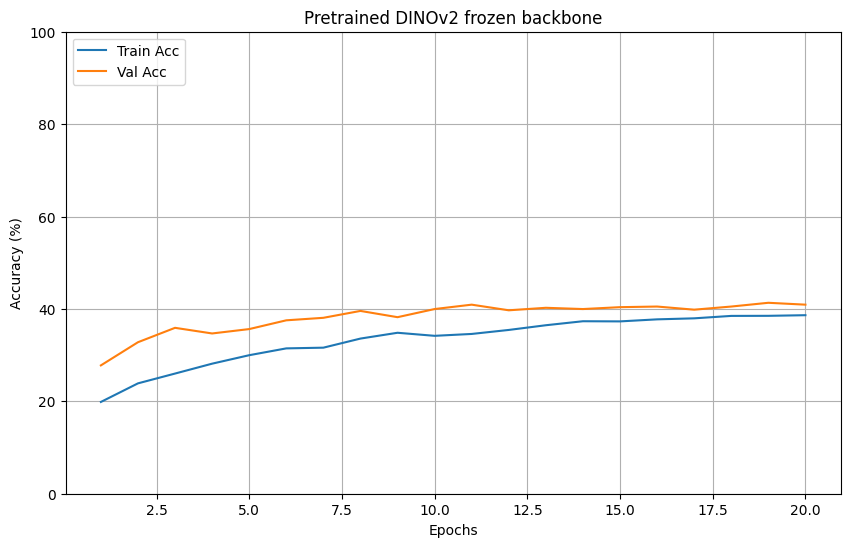


Final Test Accuracy: 43.24%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2_small",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone="freeze_all",
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-4
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained DINOv2 frozen backbone")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained DINOv2 with finetuning last transformer block + head

Loading DINOv2 Small...


Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main


Epoch 1/20 | Train: 31.05% | Val: 34.82% | LR: 0.000100
Epoch 2/20 | Train: 40.65% | Val: 41.19% | LR: 0.000100
Epoch 3/20 | Train: 43.82% | Val: 47.56% | LR: 0.000100
Epoch 4/20 | Train: 46.83% | Val: 47.56% | LR: 0.000100
Epoch 5/20 | Train: 48.57% | Val: 48.51% | LR: 0.000100
Epoch 6/20 | Train: 50.19% | Val: 47.70% | LR: 0.000100
Epoch 7/20 | Train: 50.65% | Val: 49.05% | LR: 0.000100
Epoch 8/20 | Train: 52.22% | Val: 51.76% | LR: 0.000100
Epoch 9/20 | Train: 53.70% | Val: 54.88% | LR: 0.000100
Epoch 10/20 | Train: 54.60% | Val: 53.12% | LR: 0.000100
Epoch 11/20 | Train: 54.28% | Val: 53.93% | LR: 0.000100
Epoch 12/20 | Train: 55.82% | Val: 53.66% | LR: 0.000100
Epoch 13/20 | Train: 56.57% | Val: 52.71% | LR: 0.000100
Epoch 14/20 | Train: 56.64% | Val: 52.98% | LR: 0.000100
Epoch 15/20 | Train: 57.79% | Val: 54.61% | LR: 0.000100
Epoch 16/20 | Train: 57.91% | Val: 54.20% | LR: 0.000100
Epoch 17/20 | Train: 59.39% | Val: 47.43% | LR: 0.000100
Epoch 18/20 | Train: 59.08% | Val: 55.56

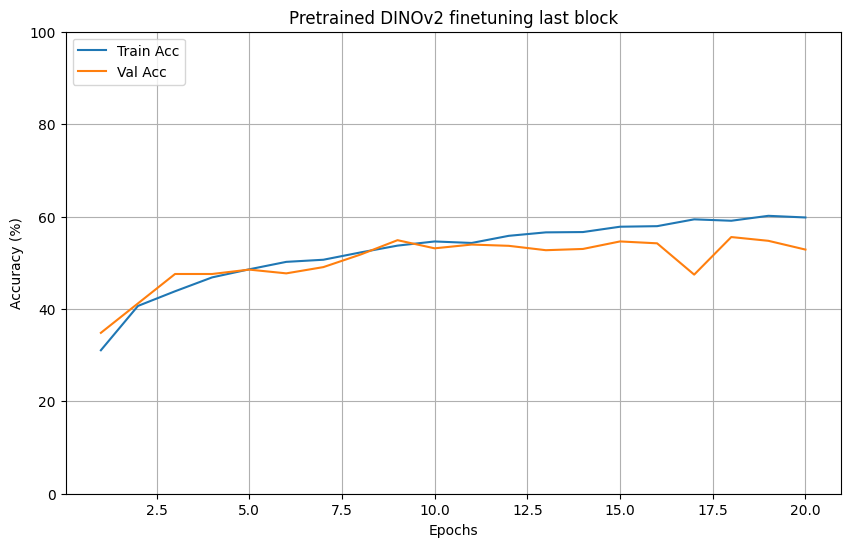


Final Test Accuracy: 56.88%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2_small",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone="freeze_except_last",
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-4
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained DINOv2 finetuning last block")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained DINOv2 with finetuning last 3 transformer blocks + head

Loading DINOv2 Small...


Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Epoch 1/20 | Train: 31.66% | Val: 41.87% | LR: 0.000100
Epoch 2/20 | Train: 40.46% | Val: 43.90% | LR: 0.000100
Epoch 3/20 | Train: 47.40% | Val: 47.83% | LR: 0.000100
Epoch 4/20 | Train: 49.80% | Val: 49.59% | LR: 0.000100
Epoch 5/20 | Train: 53.28% | Val: 52.17% | LR: 0.000100
Epoch 6/20 | Train: 54.67% | Val: 51.49% | LR: 0.000100
Epoch 7/20 | Train: 56.76% | Val: 54.61% | LR: 0.000100
Epoch 8/20 | Train: 58.06% | Val: 55.42% | LR: 0.000100
Epoch 9/20 | Train: 59.76% | Val: 54.74% | LR: 0.000100
Epoch 10/20 | Train: 61.38% | Val: 55.28% | LR: 0.000100
Epoch 11/20 | Train: 61.19% | Val: 54.74% | LR: 0.000100
Epoch 12/20 | Train: 63.34% | Val: 53.93% | LR: 0.000100
Epoch 13/20 | Train: 63.40% | Val: 55.28% | LR: 0.000100
Epoch 14/20 | Train: 64.36% | Val: 53.66% | LR: 0.000100
Epoch 15/20 | Train: 65.59% | Val: 58.13% | LR: 0.000100
Epoch 16/20 | Train: 66.81% | Val: 55.15% | LR: 0.000100
Epoch 17/20 | Train: 68.05% | Val: 52.17% | LR: 0.000100
Epoch 18/20 | Train: 67.15% | Val: 55.83

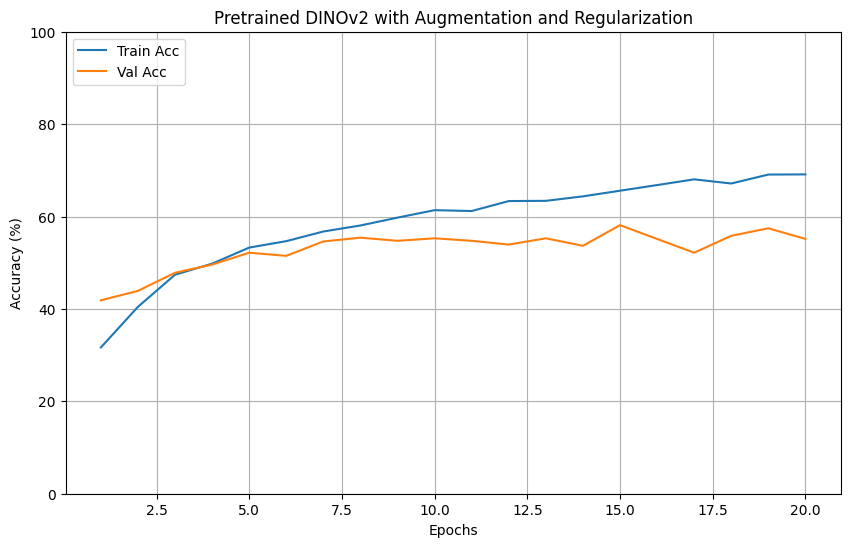


Final Test Accuracy: 57.13%


In [ ]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2_small",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone="freeze_except_last_three",
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-4
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained DINOv2 with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

### DINOv2 final version

- Using the best configuration of finetuning/freezing transformer blocks
- Using pretrained model
- Using augmentation and regularization
- Using LR scheduler

Loading DINOv2 Small...


Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main


Epoch 1/30 | Train: 28.83% | Val: 41.19% | LR: 0.000100
Epoch 2/30 | Train: 40.98% | Val: 41.46% | LR: 0.000100
Epoch 3/30 | Train: 46.47% | Val: 48.37% | LR: 0.000100
Epoch 4/30 | Train: 51.46% | Val: 52.98% | LR: 0.000100
Epoch 5/30 | Train: 53.45% | Val: 52.44% | LR: 0.000100
Epoch 6/30 | Train: 54.50% | Val: 52.17% | LR: 0.000100
Epoch 7/30 | Train: 57.25% | Val: 51.49% | LR: 0.000050
Epoch 8/30 | Train: 60.87% | Val: 55.28% | LR: 0.000050
Epoch 9/30 | Train: 62.28% | Val: 56.10% | LR: 0.000050
Epoch 10/30 | Train: 63.41% | Val: 57.32% | LR: 0.000050
Epoch 11/30 | Train: 64.86% | Val: 56.50% | LR: 0.000050
Epoch 12/30 | Train: 65.06% | Val: 55.15% | LR: 0.000050
Epoch 13/30 | Train: 66.64% | Val: 56.91% | LR: 0.000025
Epoch 14/30 | Train: 69.07% | Val: 55.56% | LR: 0.000025
Epoch 15/30 | Train: 69.81% | Val: 57.05% | LR: 0.000025
Epoch 16/30 | Train: 71.68% | Val: 55.96% | LR: 0.000013
Epoch 17/30 | Train: 73.29% | Val: 56.91% | LR: 0.000013
Epoch 18/30 | Train: 74.94% | Val: 56.37

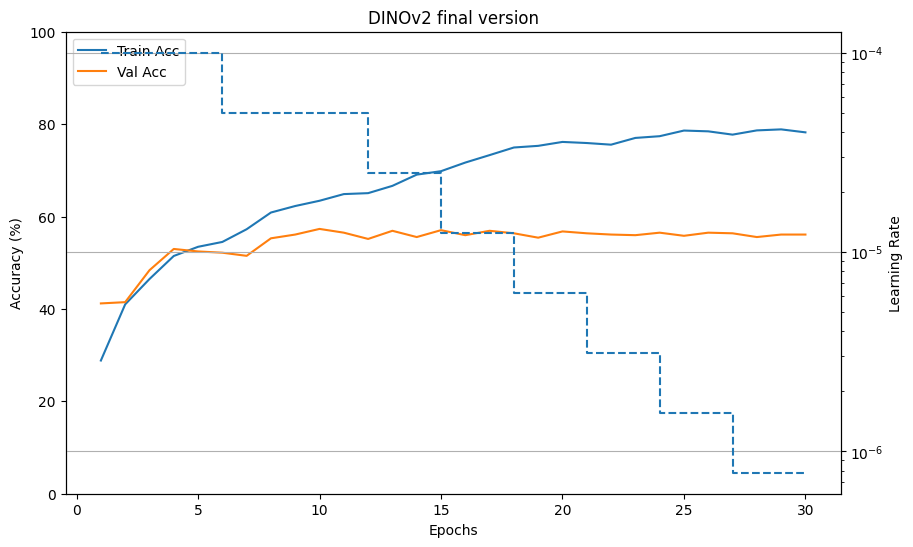


Final Test Accuracy: 60.69%


In [5]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2_small",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone="freeze_except_last_three",
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-4,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, scheduler=scheduler, epochs=30)

plot_history(history, "DINOv2 final version")

test_accuracy = evaluate_model(model, test_loader)